In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import psycopg2
from datetime import datetime

In [ ]:
from config import db_conn
conn = db_conn()

symbol = 'FEDERALBNK-I'
from_date = '2025-10-01'
to_date = '2025-10-31'

query = f"""
    SELECT date AT TIME ZONE 'Asia/Kolkata' AS local_time, *
    FROM idata_15min
    WHERE symbol = %s AND date(date) >= %s AND date(date) <= %s
    ORDER BY date ASC;
"""
params = (symbol, from_date, to_date)

cursor = conn.cursor()
cursor.execute(query, params)
rows = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]

df = pd.DataFrame(rows, columns=columns)
df['date'] = df["local_time"]
# df["date"] = pd.to_datetime(df["date"])
df.drop(columns=["local_time", "id"], inplace=True)


In [ ]:
df = pd.read_csv("/Users/saravanakumar/Desktop/dataset.csv")
df["date"] = pd.to_datetime(df["date"])

In [54]:
n=10
df["pivot_high"] = df["high"][(df["high"] == df["high"].rolling(window=2*n+1, center=True).max())]
df["pivot_low"] = df["low"][(df["low"] == df["low"].rolling(window=2*n+1, center=True).min())]

df[["date", "pivot_high", "pivot_low"]].to_clipboard(index=False)

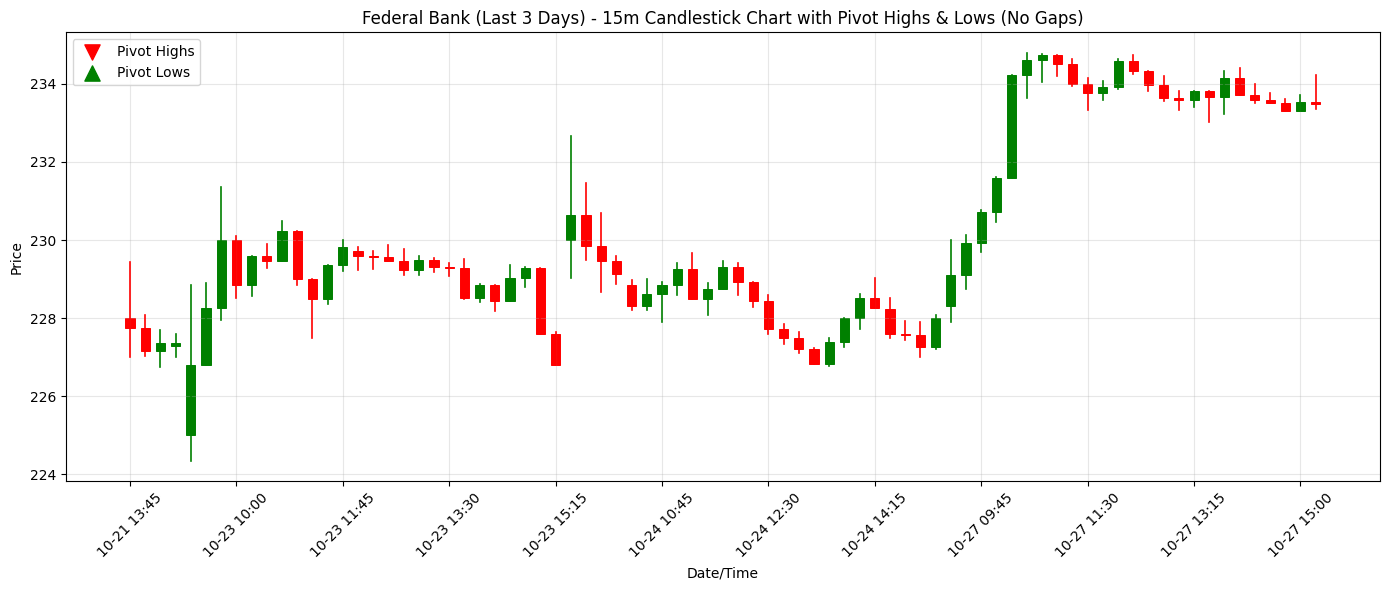

In [49]:
df_sorted = df.sort_values("date")
unique_days = df_sorted["date"].dt.date.unique()[-4:]  # last unique date
last_3_days_data = df_sorted[df_sorted["date"].dt.date.isin(unique_days)]


# Assume df_sorted and last_3_days_data are already defined
last_3_days_data = last_3_days_data.reset_index(drop=True)
last_3_days_data["x"] = range(len(last_3_days_data))  # integer trading index

fig, ax = plt.subplots(figsize=(14, 6))

# Plot candlesticks
for _, row in last_3_days_data.iterrows():
    color = "green" if row["close"] >= row["open"] else "red"
    ax.plot([row["x"], row["x"]], [row["low"], row["high"]], color=color, linewidth=1.2)
    ax.add_patch(Rectangle(
        (row["x"] - 0.3, min(row["open"], row["close"])),
        0.6,
        abs(row["close"] - row["open"]),
        facecolor=color,
        edgecolor=color,
        linewidth=0.7
    ))

# Mark pivots
ax.scatter(
    last_3_days_data.loc[last_3_days_data["pivot_high"].notna(), "x"],
    last_3_days_data.loc[last_3_days_data["pivot_high"].notna(), "pivot_high"],
    color="red", marker="v", s=120, label="Pivot Highs", zorder=5
)
ax.scatter(
    last_3_days_data.loc[last_3_days_data["pivot_low"].notna(), "x"],
    last_3_days_data.loc[last_3_days_data["pivot_low"].notna(), "pivot_low"],
    color="green", marker="^", s=120, label="Pivot Lows", zorder=5
)

# Format x-axis with actual datetimes (for readability)
N = len(last_3_days_data) // 10 or 1
ax.set_xticks(last_3_days_data["x"][::N])
ax.set_xticklabels(
    last_3_days_data["date"].dt.strftime("%m-%d %H:%M")[::N],
    rotation=45,
)

ax.set_title("Federal Bank (Last 3 Days) - 15m Candlestick Chart with Pivot Highs & Lows (No Gaps)")
ax.set_xlabel("Date/Time")
ax.set_ylabel("Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()


